In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

import shap

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
df = pd.read_csv("../artifacts/chiller_data.csv")   
df = df.sample(n=20000, random_state=42).reset_index(drop=True)
print("Shape:", df.shape)
df.head()


Shape: (20000, 17)


,month,day_of_month,hour,outdoor_temperature,outdoor_humidity,wind_speed,wind_direction,diffuse_solar_radiation,direct_solar_radiation,air_temperature,air_humidity,people_occupant,htg_setpoint,clg_setpoint,co2_emission,HVAC_electricity_demand_rate,total_electricity_HVAC
0,9.0,25.0,22.0,14.534932,94.628372,3.10,50.0,0.0,0.0,21.204252,63.905396,0.0,19.0,23.25,0.0,87.036232,7.833261e+04
1,12.0,12.0,6.0,1.685171,90.161842,3.60,20.0,0.0,0.0,21.000399,37.206902,0.0,21.0,23.25,0.0,7569.806152,6.812826e+06
2,11.0,10.0,0.0,12.627542,97.922203,7.95,120.0,0.0,0.0,20.316967,62.746147,0.0,16.0,26.00,0.0,87.036232,7.833261e+04
3,11.0,3.0,0.0,11.735832,56.796844,5.90,355.0,0.0,0.0,21.000000,31.807304,0.0,21.0,23.25,0.0,2681.193604,2.413074e+06
4,1.0,25.0,1.0,2.770959,60.532803,8.25,310.0,0.0,0.0,20.999981,37.316830,0.0,21.0,23.25,0.0,5959.118652,5.363207e+06


In [4]:
target_col = "HVAC_electricity_demand_rate"

drop_cols = [
    target_col,
    "total_electricity_HVAC",
    "month",
    "day_of_month",
    "hour",
    # 若你不想把 setpoint 當 feature 可加入:
    # "htg_setpoint", "clg_setpoint"
]

# 過濾出 feature 欄位
drop_cols = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

print("Target:", target_col)
print("Features:", feature_cols)

X = df[feature_cols]
y = df[target_col]


Target: HVAC_electricity_demand_rate
Features: ['outdoor_temperature', 'outdoor_humidity', 'wind_speed', 'wind_direction', 'diffuse_solar_radiation', 'direct_solar_radiation', 'air_temperature', 'air_humidity', 'people_occupant', 'htg_setpoint', 'clg_setpoint', 'co2_emission']


,feature,abs_pearson_corr
0,htg_setpoint,0.506126
1,clg_setpoint,0.410696
2,outdoor_temperature,0.325079
3,air_humidity,0.146296
4,air_temperature,0.141245
5,wind_speed,0.132922
6,outdoor_humidity,0.124579
7,wind_direction,0.066664
8,people_occupant,0.008923
9,diffuse_solar_radiation,0.005601


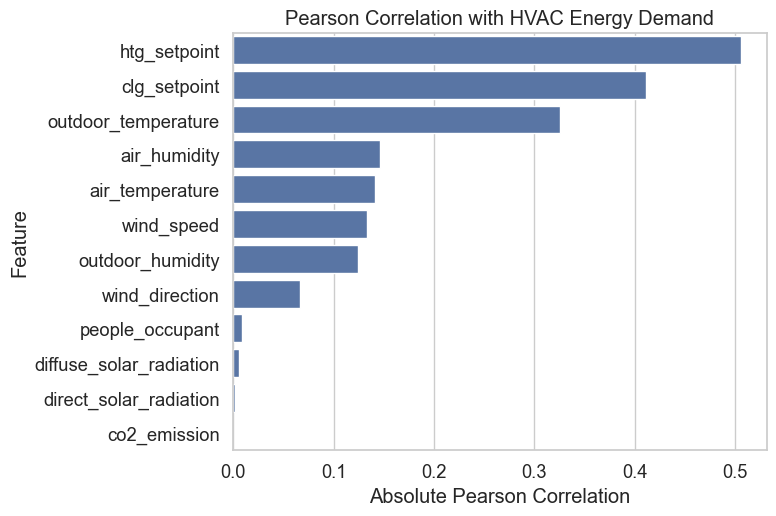

In [5]:
corr_series = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
corr_df = corr_series.abs().sort_values(ascending=False).reset_index()
corr_df.columns = ["feature", "abs_pearson_corr"]

display(corr_df)

plt.figure(figsize=(8, len(corr_df)*0.45))
sns.barplot(data=corr_df, x="abs_pearson_corr", y="feature")
plt.title("Pearson Correlation with HVAC Energy Demand")
plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


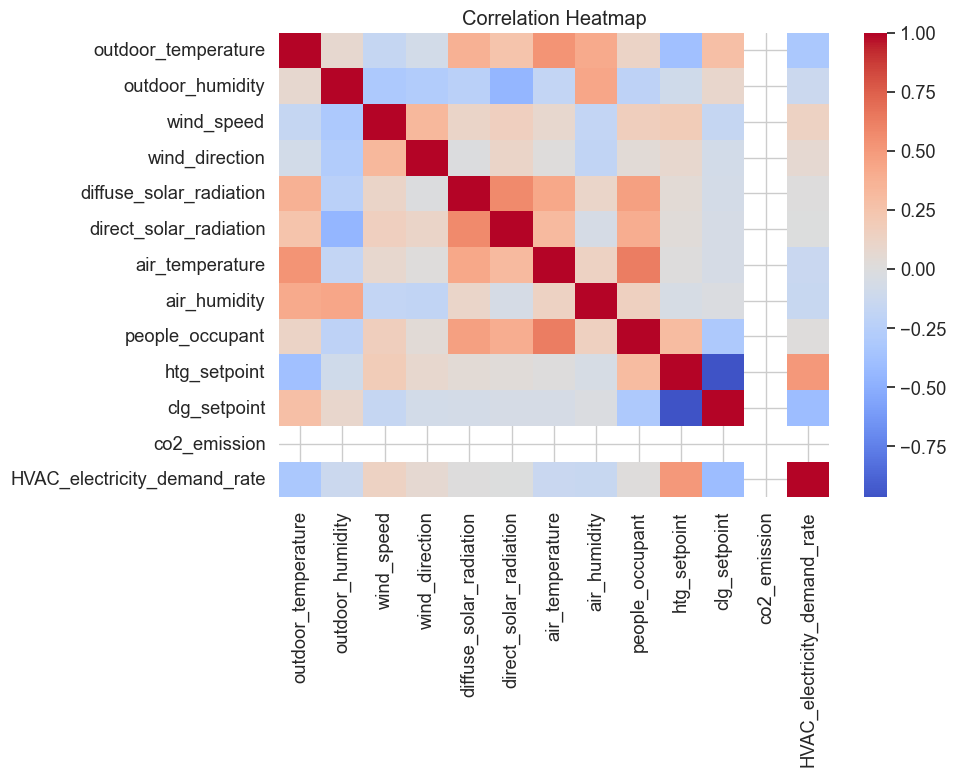

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols + [target_col]].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Train R^2:", rf.score(X_train, y_train))
print("Test  R^2:", rf.score(X_test, y_test))


Train R^2: 0.9915761886285944
Test  R^2: 0.9454333498605244


,feature,importance_mean,importance_std
11,co2_emission,0.000000,0.000000
3,wind_direction,0.004022,0.000678
2,wind_speed,0.009564,0.000668
5,direct_solar_radiation,0.018710,0.001293
4,diffuse_solar_radiation,0.018793,0.001796
1,outdoor_humidity,0.019936,0.001653
7,air_humidity,0.035734,0.001725
10,clg_setpoint,0.041008,0.001563
8,people_occupant,0.125213,0.006790
6,air_temperature,0.647247,0.015309


C:\Users\USER\AppData\Local\Temp\ipykernel_53440\704248564.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


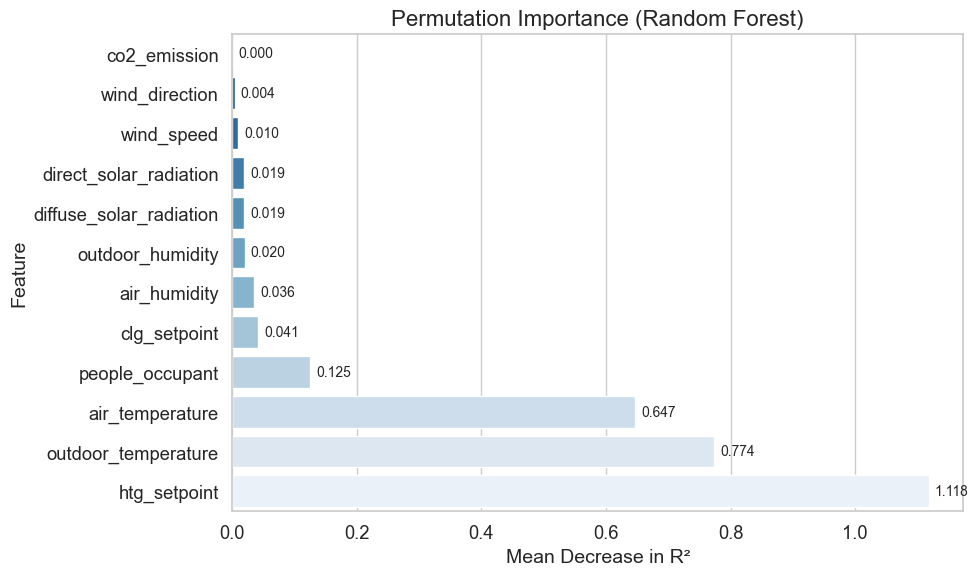

In [10]:
# --- Permutation Importance (improved version) ---

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=8,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

# Sort from small → large for better visualization
perm_df_sorted = perm_df.sort_values("importance_mean", ascending=True)

display(perm_df_sorted)

# Improved plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=perm_df_sorted,
    x="importance_mean",
    y="feature",
    palette="Blues_r"
)

plt.title("Permutation Importance (Random Forest)", fontsize=16)
plt.xlabel("Mean Decrease in R²", fontsize=14)
plt.ylabel("Feature", fontsize=14)

# Add numeric labels to bars
for i, v in enumerate(perm_df_sorted["importance_mean"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


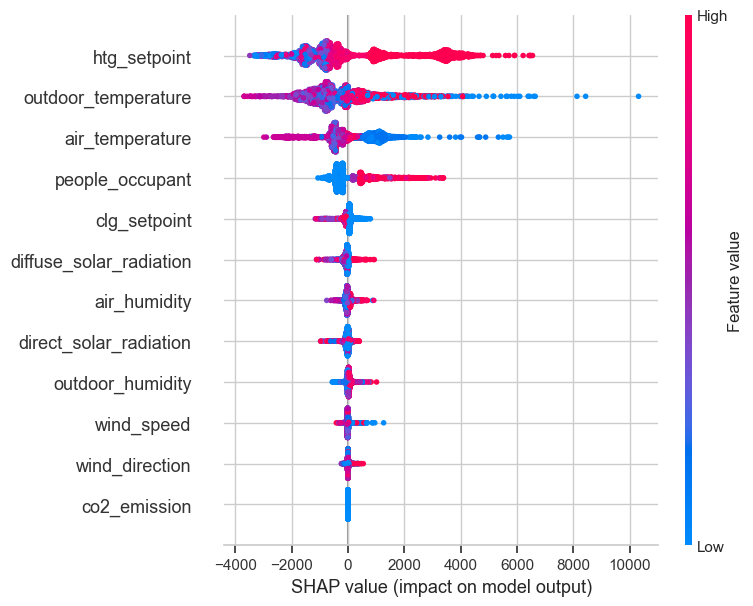

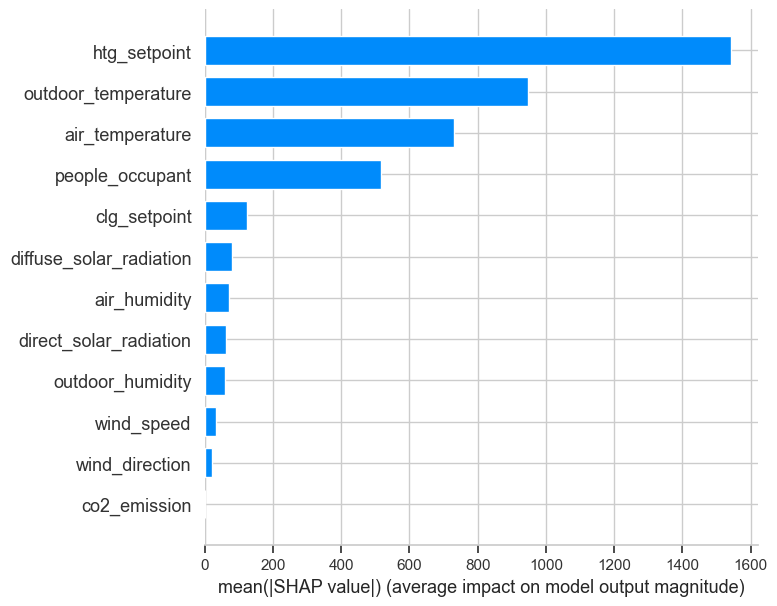

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary scatter plot
shap.summary_plot(shap_values, X_test)

# Summary bar plot（適合報告）
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [12]:
pearson_s = corr_df.set_index("feature")["abs_pearson_corr"]
perm_s = perm_df.set_index("feature")["importance_mean"]

summary = pd.concat([pearson_s, perm_s], axis=1)
summary.columns = ["pearson_corr", "perm_importance"]
summary = summary.fillna(0).sort_values("perm_importance", ascending=False)

display(summary)


,pearson_corr,perm_importance
feature,,
htg_setpoint,0.506126,1.117869
outdoor_temperature,0.325079,0.773788
air_temperature,0.141245,0.647247
people_occupant,0.008923,0.125213
clg_setpoint,0.410696,0.041008
air_humidity,0.146296,0.035734
outdoor_humidity,0.124579,0.019936
diffuse_solar_radiation,0.005601,0.018793
direct_solar_radiation,0.002077,0.018710


In [13]:
top_k = 5
top_features = summary.head(top_k).index.tolist()

summary_text = (
    "Based on Pearson correlation, permutation importance, and SHAP analysis, "
    f"the most influential variables affecting {target_col} are: "
    + ", ".join(top_features[:-1])
    + f", and {top_features[-1]}. "
    "These variables have the strongest impact on momentary HVAC energy demand."
)

print(summary_text)


Based on Pearson correlation, permutation importance, and SHAP analysis, the most influential variables affecting HVAC_electricity_demand_rate are: htg_setpoint, outdoor_temperature, air_temperature, people_occupant, and clg_setpoint. These variables have the strongest impact on momentary HVAC energy demand.
